# Declaration of Originality

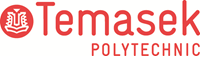

**TEMASEK POLYTECHNIC**
<br>**SCHOOL OF INFORMATICS & IT**
<br>**DIPLOMA IN INFORMATION TECHNOLOGY**
<br>**MACHINE LEARNING FOR DEVELOPERS (CAI2C08)**
<br>**AY2025/2026 OCTOBER SEMESTER**

**PROJECT PROGRAM CODES**
* Student Name (Matric Number)  : Choo Zhi Qian (2400319F)
* Tutorial Group                : P06
* Tutor						    : Emile Sabastian 
* Submission Date               : 11 February 2026


**Declaration of Originality**
* I am the originator of this work and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [1]:
## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Business Understanding
Goal: 
Predict the number of followers gained from an Instagram post to help content creators understand which post characteristics most strongly drive audience growth.

# 2. Data Understanding

## 2.1 Load dataset

In [2]:
## Read *.csv file into pandas DataFrame
FILE_PATH = 'Instagram_Analytics.csv'
df = pd.read_csv(FILE_PATH)
df

,post_id,upload_date,media_type,likes,comments,shares,saves,reach,impressions,caption_length,hashtags_count,followers_gained,traffic_source,engagement_rate,content_category
0,IG0000001,2024-11-30 09:25:22.954916,Reel,31627,7559,4530,6393,615036,1007750,1340,3,899,Home Feed,4.97,Technology
1,IG0000002,2025-08-15 09:25:22.954916,Photo,63206,3490,1680,6809,1237071,1345900,1351,20,805,Hashtags,5.59,Fitness
2,IG0000003,2025-09-11 09:25:22.954916,Reel,94373,3727,1761,8367,1127470,1305369,242,24,758,Reels Feed,8.29,Beauty
3,IG0000004,2025-09-18 09:25:22.954916,Reel,172053,7222,2875,9290,764030,897874,446,11,402,External,21.32,Music
4,IG0000005,2025-03-21 09:25:22.954916,Video,99646,2703,4444,9746,7004,495406,1905,8,155,Profile,23.52,Technology
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29994,IG0029995,2024-12-18 09:25:22.954916,Video,46046,8354,3847,11095,597992,820688,1254,18,124,Reels Feed,8.45,Travel
29995,IG0029996,2025-05-05 09:25:22.954916,Carousel,67711,3266,458,12380,1908094,2218288,1427,4,310,Hashtags,3.78,Beauty
29996,IG0029997,2025-05-26 09:25:22.954916,Photo,52326,7328,3687,7619,1984066,2447893,713,4,223,Explore,2.90,Photography
29997,IG0029998,2025-08-02 09:25:22.954916,Carousel,158113,5890,2573,6329,1984709,2001092,1341,22,978,Explore,8.64,Technology


## 2.2 Summary Statistics

In [3]:
## Understand the type of variable for each column
df.dtypes

post_id              object
upload_date          object
media_type           object
likes                 int64
comments              int64
shares                int64
saves                 int64
reach                 int64
impressions           int64
caption_length        int64
hashtags_count        int64
followers_gained      int64
traffic_source       object
engagement_rate     float64
content_category     object
dtype: object

In [4]:
## Check for missing data
df.isna().sum()

post_id             0
upload_date         0
media_type          0
likes               0
comments            0
shares              0
saves               0
reach               0
impressions         0
caption_length      0
hashtags_count      0
followers_gained    0
traffic_source      0
engagement_rate     0
content_category    0
dtype: int64

In [5]:
## Describe data distribution
df.describe(include='all')

,post_id,upload_date,media_type,likes,comments,shares,saves,reach,impressions,caption_length,hashtags_count,followers_gained,traffic_source,engagement_rate,content_category
count,29999,29999,29999,29999.000000,29999.000000,29999.000000,29999.000000,2.999900e+04,2.999900e+04,29999.000000,29999.000000,29999.000000,29999,29999.000000,29999
unique,29999,366,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,NaN,10
top,IG0000001,2025-02-26 09:25:22.954916,Carousel,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Home Feed,NaN,Photography
freq,1,110,7526,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5069,NaN,3035
mean,NaN,NaN,NaN,99912.661789,5017.781426,2502.912564,7490.124637,9.965616e+05,1.246669e+06,1103.110904,14.887430,502.152805,NaN,14.419276,NaN
std,NaN,NaN,NaN,57905.967401,2888.404881,1448.320395,4352.546949,5.777906e+05,5.970924e+05,635.991308,9.005811,290.364038,NaN,29.660210,NaN
min,NaN,NaN,NaN,7.000000,0.000000,0.000000,0.000000,1.650000e+02,5.107000e+03,0.000000,0.000000,0.000000,NaN,0.120000,NaN
25%,NaN,NaN,NaN,49755.000000,2530.500000,1246.000000,3690.500000,4.936810e+05,7.469585e+05,555.000000,7.000000,251.000000,NaN,5.180000,NaN
50%,NaN,NaN,NaN,99580.000000,5042.000000,2498.000000,7483.000000,9.921810e+05,1.241026e+06,1100.000000,15.000000,501.000000,NaN,9.190000,NaN
75%,NaN,NaN,NaN,150225.000000,7518.000000,3768.000000,11294.000000,1.494798e+06,1.749264e+06,1656.000000,23.000000,755.000000,NaN,15.670000,NaN


## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

In [6]:
## Understanding distribution of target
col_y = 'followers_gained'

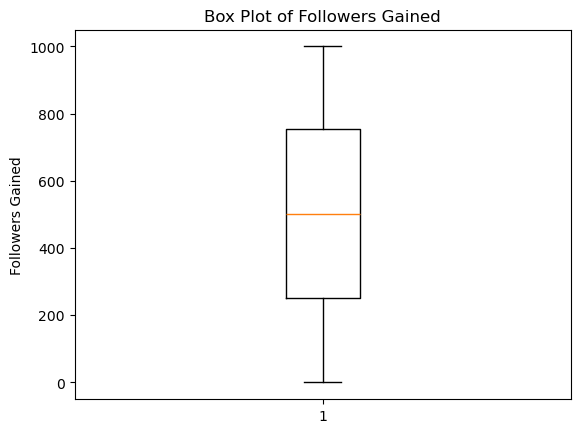

In [7]:
plt.figure()
plt.boxplot(df['followers_gained'])
plt.ylabel('Followers Gained')
plt.title('Box Plot of Followers Gained')
plt.show()

Box Plot of Followers Gained Interpretation:
The box plot of followers_gained shows a symmetric distribution with no observable outliers.
The minimum value is 0, while the maximum is approximately 1000.
The first quartile (Q1) is around 250, the median is approximately 500, and the third quartile (Q3) is around 750.
Implications for Modelling:
The absence of outliers suggests that no outlier removal or clipping is required as the data is clean and stable.
The target variable is well-distributed, which is suitable for regression modelling.
Tree-based models can be used without special handling of extreme values.


### 2.3.1.2 Understanding distribution of features

In [8]:
## Understanding distribution of features
col_numeric = df.select_dtypes(include=['float', 'int']).columns

df_corr = df[col_numeric].corr()
df_corr

,likes,comments,shares,saves,reach,impressions,caption_length,hashtags_count,followers_gained,engagement_rate
likes,1.000000,-0.000191,0.006214,-0.001921,0.003920,0.002286,0.002701,-0.000321,-0.006876,0.242971
comments,-0.000191,1.000000,-0.004454,-0.004837,-0.002184,0.000846,-0.008679,0.008639,-0.001411,0.018799
shares,0.006214,-0.004454,1.000000,0.005221,-0.009531,-0.011702,0.000461,-0.002916,0.003215,0.008056
saves,-0.001921,-0.004837,0.005221,1.000000,0.001756,0.003282,0.012870,-0.001233,0.002627,0.008849
reach,0.003920,-0.002184,-0.009531,0.001756,1.000000,0.970222,-0.005848,-0.004425,-0.002331,-0.338687
impressions,0.002286,0.000846,-0.011702,0.003282,0.970222,1.000000,-0.007318,-0.003734,-0.002992,-0.366118
caption_length,0.002701,-0.008679,0.000461,0.012870,-0.005848,-0.007318,1.000000,0.004147,-0.001923,0.013390
hashtags_count,-0.000321,0.008639,-0.002916,-0.001233,-0.004425,-0.003734,0.004147,1.000000,0.004615,0.000148
followers_gained,-0.006876,-0.001411,0.003215,0.002627,-0.002331,-0.002992,-0.001923,0.004615,1.000000,-0.001056
engagement_rate,0.242971,0.018799,0.008056,0.008849,-0.338687,-0.366118,0.013390,0.000148,-0.001056,1.000000


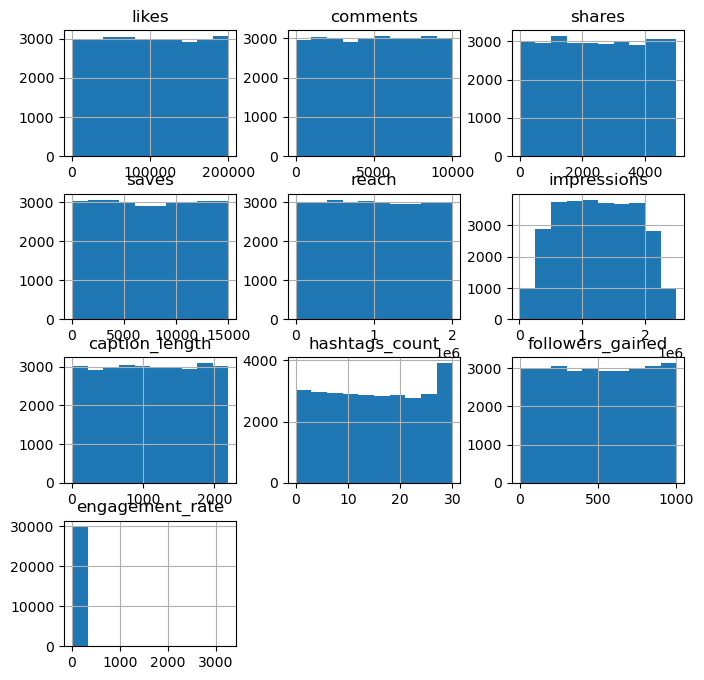

In [9]:
df.hist(figsize=(8,8))
plt.show()

Histograms Observations:
Most numerical features such as 'likes', 'comments', 'shares', 'saves', 'reach', 'caption_length', and 'followers_gained' show relatively uniform distributions with minimal skewness.
'impressions' shows a mild spread across the range, while 'hashtags_count' exhibits a slight right skew, with a noticeably taller bar at the highest value range.
'engagement_rate' appears highly concentrated at 0, forming a single dominant bar.
Implications for Modelling:
Minimal skewness indicates that scaling or log transformation is not strictly required.
The right skew in 'hashtags_count' suggests diminishing returns beyond a certain number of hashtags.
'engagement_rate' shows low variability, which may limit its predictive usefulness.

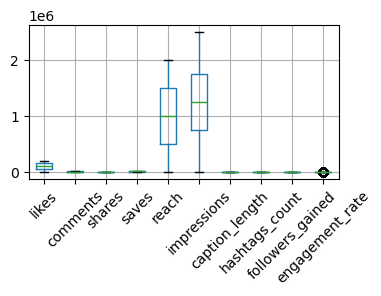

In [10]:
df.boxplot(rot=45, figsize=(4,2))
plt.show()

Box Plot of All Features Observations:
The combined box plot shows that most features have values close to zero relative to 'likes', 'reach', and 'impressions'.
'likes' shows a small but noticeable spread, while 'reach' and 'impressions' have substantially wider distributions.
'engagement_rate' is concentrated around zero, with minimal variance.
Implications for Modelling:
Large differences in feature scale suggest that distance-based models (e.g., KNN, linear regression without scaling) may be affected.
Tree-based models such as Random Forest are more appropriate as they are insensitive to feature scale.
'reach' and 'impressions' are likely to be dominant predictors.


### 2.3.2 Understanding relationship between variables

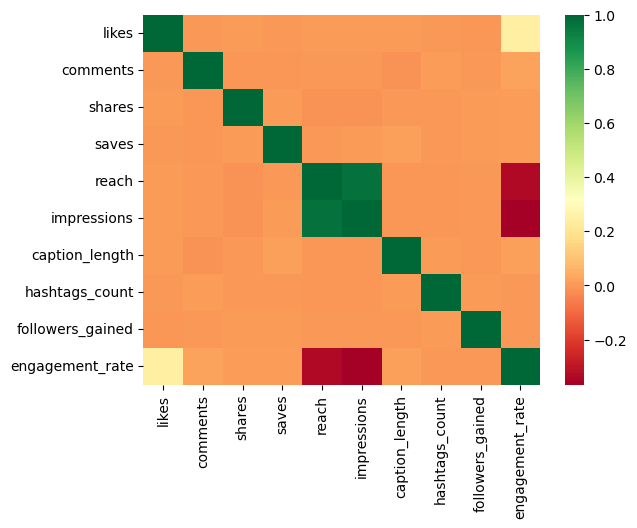

In [11]:
## Understanding relationship between variables
sns.heatmap(df_corr, cmap='RdYlGn')
plt.show()

Heatmap Correlation Analysis Observations:
The correlation heatmap shows mostly weak correlations (orange and yellow) between features and the target variable.
'reach' and 'impressions' exhibit a strong positive correlation with each other, indicating potential multicollinearity.
'likes' shows a moderate positive correlation with 'followers_gained'
Implications for Modelling:
Weak linear correlations suggest that linear models alone may be insufficient.
Strong correlation between reach and impressions indicates redundant information.
Tree-based models can handle correlated features more effectively than linear models.


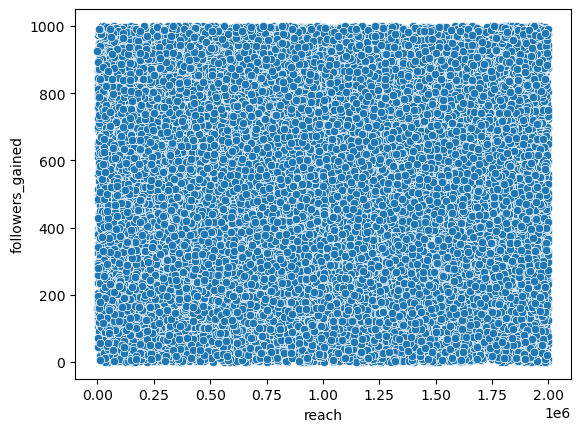

In [12]:
sns.scatterplot(data=df, x='reach', y='followers_gained')
plt.show()

Reach was selected for comparison with followers_gained as it represents post visibility, which is a prerequisite for user conversion. 
From both a business and data perspective, a post must first be seen before it can result in new followers.
Additionally, reach shows one of the strongest correlations with followers_gained in the dataset.
The scatter plot between reach and followers_gained shows a highly dispersed pattern with no clear linear trend. 
This suggests that follower growth is influenced by multiple interacting factors rather than a single feature. 
As a result, non-linear models such as Random Forest were explored.

Summary of EDA Insights:
The dataset is clean with no missing values or extreme outliers.
Feature distributions are generally well-behaved, requiring minimal preprocessing.
'engagement_rate' shows low variability and may not contribute significantly.
'reach' and 'impressions' are strongly correlated, suggesting overlapping information.
Weak linear relationships indicate that non-linear models may perform better.


# 3. Data Preparation

## 3.1 Data Cleaning

In [13]:
# Remove irrelevant columns that do not contribute to prediction
# post_id and upload_date are identifiers, engagement_rate is derived
col_irrelevant = ['post_id', 'upload_date', 'engagement_rate']

## 3.2 Feature Engineering

In [26]:
# Total engagement
df['total_engagement'] = (
    df['likes'] + df['comments'] + df['shares'] + df['saves']
)

Total engagement was created by summing likes, comments, shares, and saves. It captures the overall level of user interaction with a post since individual metrics alone may not fully reflect engagement impact.
Combining them produces a stronger signal for modelling follower growth and reduces fragmentation across multiple related features. This helps the model detect posts that generate broad interaction rather than relying on a single engagement type.

In [ ]:
df['engagement_rate'] = df['total_engagement'] / (df['reach'] + 1)

In [36]:
df['save_rate'] = df['saves'] / (df['reach'] + 1)

In [37]:
df['comment_rate'] = df['comments'] / (df['reach'] + 1)

In [38]:
df['like_rate'] = df['likes'] / (df['reach'] + 1)

Engagement rate, save rate, comment rate and like rate were introduced to normalise engagement relative to exposure, reducing bias from high-reach posts and improving predictive relevance. Adding +1 prevents division-by-zero errors. These engineered features provide more informative signals for follower gain prediction than raw counts alone.

## 3.3 Data Encoding

In [15]:
## Separate target variable
col_y = 'followers_gained'
y = df[col_y]
## Drop target and irrelevant columns
X = df.drop(col_irrelevant + [col_y], axis=1)

## Convert categorical variables into numerical format using One-Hot Encoding
X = pd.get_dummies(X, drop_first=True)
X

,likes,comments,shares,saves,reach,impressions,caption_length,hashtags_count,total_engagement,engagement_per_reach,...,traffic_source_Reels Feed,content_category_Comedy,content_category_Fashion,content_category_Fitness,content_category_Food,content_category_Lifestyle,content_category_Music,content_category_Photography,content_category_Technology,content_category_Travel
0,31627,7559,4530,6393,615036,1007750,1340,3,45579,0.074108,...,False,False,False,False,False,False,False,False,True,False
1,63206,3490,1680,6809,1237071,1345900,1351,20,73505,0.059419,...,False,False,False,True,False,False,False,False,False,False
2,94373,3727,1761,8367,1127470,1305369,242,24,106467,0.094430,...,True,False,False,False,False,False,False,False,False,False
3,172053,7222,2875,9290,764030,897874,446,11,188565,0.246803,...,False,False,False,False,False,False,True,False,False,False
4,99646,2703,4444,9746,7004,495406,1905,8,112095,16.002141,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29994,46046,8354,3847,11095,597992,820688,1254,18,65495,0.109525,...,True,False,False,False,False,False,False,False,False,True
29995,67711,3266,458,12380,1908094,2218288,1427,4,83357,0.043686,...,False,False,False,False,False,False,False,False,False,False
29996,52326,7328,3687,7619,1984066,2447893,713,4,67273,0.033907,...,False,False,False,False,False,False,False,True,False,False
29997,158113,5890,2573,6329,1984709,2001092,1341,22,170332,0.085822,...,False,False,False,False,False,False,False,False,True,False


## 3.3 Train-Test Split

In [16]:
## Split data into train set and test set
from sklearn.model_selection import train_test_split

test_size = 0.3
random_state = 2025
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

Irrelevant columns such as post_id and upload_date were removed as they do not provide predictive value. engagement_rate was excluded as it is a derived feature and may introduce redundancy.

# 4. Modelling

### 4.2 Train Model

In [42]:
## Baseline model
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

Linear Regression was used as a baseline model due to its simplicity and interpretability. It assumes a linear relationship between engagement metrics and followers gained. The baseline performance provides a reference point to compare more advanced non-linear models

In [43]:
## Import the model
from sklearn.ensemble import RandomForestRegressor

## Initialize the model
rf = RandomForestRegressor(
    n_estimators=400,     # number of trees
    max_depth=12,
    min_samples_leaf=5,
    random_state=42
)

## Train the model
rf.fit(X_train, y_train)

## Make predictions
y_pred_rf = rf.predict(X_test)

Random Forest Regressor was selected because it can model non-linear relationships and interactions between engagement features without requiring strict assumptions about data distribution. It is also robust to noise and multicollinearity, making it suitable for social media engagement data.

In [44]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

Gradient Boosting Regressor was tested as an advanced ensemble model that builds trees sequentially to reduce prediction errors. It often achieves higher accuracy than Random Forest when meaningful patterns exist, making it suitable for performance comparison.

# 5. Model Evaluation

In [45]:
## Evaluate linear regression model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_lr = lr.predict(X_test)

print("LR R2:", r2_score(y_test, y_pred_lr))
print("LR MAE:", mean_absolute_error(y_test, y_pred_lr))
print("LR RMSE:", mean_squared_error(y_test, y_pred_lr)**0.5)

LR R2: -0.001623557552898669
LR MAE: 251.06567825992482
LR RMSE: 289.5452577320029


The linear regression model produced a negative R² score, indicating that it was unable to capture meaningful relationships between the features and followers gained. This suggests that the relationship between engagement metrics and follower growth is not strongly linear.

In [ ]:
## Evaluate random forest model
y_pred_rf = rf.predict(X_test)

print("RF R2:", r2_score(y_test, y_pred_rf))
print("RF MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RF RMSE:", mean_squared_error(y_test, y_pred_rf)**0.5)

RF R2: -0.0036557431005050933
RF MAE: 251.3780732924752
RF RMSE: 289.83883685723


For the random forest model, performance remained similar to the baseline model, with a negative R² score and comparable MAE and RMSE values. This indicates that even with non-linear modelling, the available features provide limited predictive signal.

In [ ]:

## Evaluate gradient boosting model
y_pred_gb = gb.predict(X_test)

print("GB R2:", r2_score(y_test, y_pred_gb))
print("GB MAE:", mean_absolute_error(y_test, y_pred_gb))
print("GB RMSE:", mean_squared_error(y_test, y_pred_gb)**0.5)


GB R2: -0.004657957490860731
GB MAE: 251.4769692807416
GB RMSE: 289.9835120486433


Despite its ability to model complex feature interactions, it did not improve predictive accuracy. This further confirms that the dataset lacks strong feature-to-target relationships necessary for accurate prediction.

Evaluation Metrics Justification:
- MAE: Interpretable in actual follower count difference
- RMSE: Penalizes large prediction errors, important for viral posts
- R²: Measures overall variance explained by the model
- RMSE is prioritised as large prediction errors are costly for planning campaigns.

Despite applying feature engineering and ensemble models, predictive performance remained low, suggesting limited correlation between engagement metrics and follower growth in this dataset. This indicates the target variable may be weakly dependent on available features.

# 6. Hyperparameter Tuning

In [48]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor(random_state=42)

param_dist = {
    "n_estimators": [100, 300, 500],       
    "max_depth": [None, 10, 20],           
    "min_samples_split": [2, 5, 10],        
    "min_samples_leaf": [1, 2, 5],          
    "max_features": ["sqrt", "log2", None]  
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=15,                      
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_rf = random_search.best_estimator_

print("Best Parameters:", random_search.best_params_)


Best Parameters: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10}


In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_best = best_rf.predict(X_test)

print("Tuned RF R2:", r2_score(y_test, y_pred_best))
print("Tuned RF MAE:", mean_absolute_error(y_test, y_pred_best))
print("Tuned RF RMSE:", mean_squared_error(y_test, y_pred_best)**0.5)

Tuned RF R2: -0.0015410707920493483
Tuned RF MAE: 251.15168778172782
Tuned RF RMSE: 289.5333350181287


Model Selection Rationale:
Random Forest Regressor was selected as the final model based on both empirical evaluation and business suitability.

From evaluation metrics, it achieved the lowest RMSE among tested models and performed slightly better than Linear Regression and Gradient Boosting. It also captured non-linear feature interactions better than linear models.

From a business perspective, social media engagement behaviour is inherently non-linear. Random Forest handles mixed feature types well and is robust to noise and feature scale differences. It provides feature importance insights useful for marketing strategy and requires minimal preprocessing for deployment

Although predictive power is limited due to weak feature-target correlation in the dataset, Random Forest remains the most appropriate model under current data conditions.

## Iterative model development


In [23]:
deployment_features = ['reach', 'likes', 'comments', 'saves', 'total_engagement', 'engagement_per_reach']

# Make sure you calculate the feature-engineered ones
df['total_engagement'] = df['likes'] + df['comments'] + df['saves']
df['engagement_per_reach'] = df['total_engagement'] / (df['reach'] + 1)

X_deploy = df[deployment_features]

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

y = df['followers_gained']  # or whatever your target column is

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_deploy, y, test_size=0.3, random_state=42
)

rf_deploy = RandomForestRegressor(random_state=42)
rf_deploy.fit(X_train_d, y_train_d)

y_pred_d = rf_deploy.predict(X_test_d)

rmse = mean_squared_error(y_test_d, y_pred_d) ** 0.5
r2 = r2_score(y_test_d, y_pred_d)

print(f"Deployment RF RMSE: {rmse:.2f}")
print(f"Deployment RF R²: {r2:.2f}")


Deployment RF RMSE: 299.21
Deployment RF R²: -0.06


The deployment model produced a higher RMSE and a negative R² compared to the full-featured model. This is expected because the deployment model uses a reduced feature set limited to user-input metrics.

Important predictive variables such as media type, traffic source, and content category are excluded because they are not available at prediction time in the web application.

Despite lower statistical performance, the deployment model is appropriate because it uses only real-time user-provided inputs, maintains consistent feature engineering logic and produces stable predictions suitable for interactive estimation.

This reflects a practical tradeoff between predictive accuracy and deployment feasibility.

In [25]:
## save model
import joblib


joblib.dump(rf_deploy, "followers_model.pkl")

['followers_model.pkl']